In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:

# Load dữ liệu
train = pd.read_csv('data/train (1).csv')

In [22]:

# 1. Kiểm tra thông tin tổng quát
print("--- Thông tin tổng quát ---")
print(train.info())

--- Thông tin tổng quát ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396

In [23]:

# 2. Kiểm tra giá trị thiếu
missing_data = train.isnull().sum()
print("\n--- Số lượng giá trị thiếu mỗi cột ---")
print(missing_data[missing_data > 0])


--- Số lượng giá trị thiếu mỗi cột ---
Popularity           333
key                 1609
instrumentalness    3541
dtype: int64


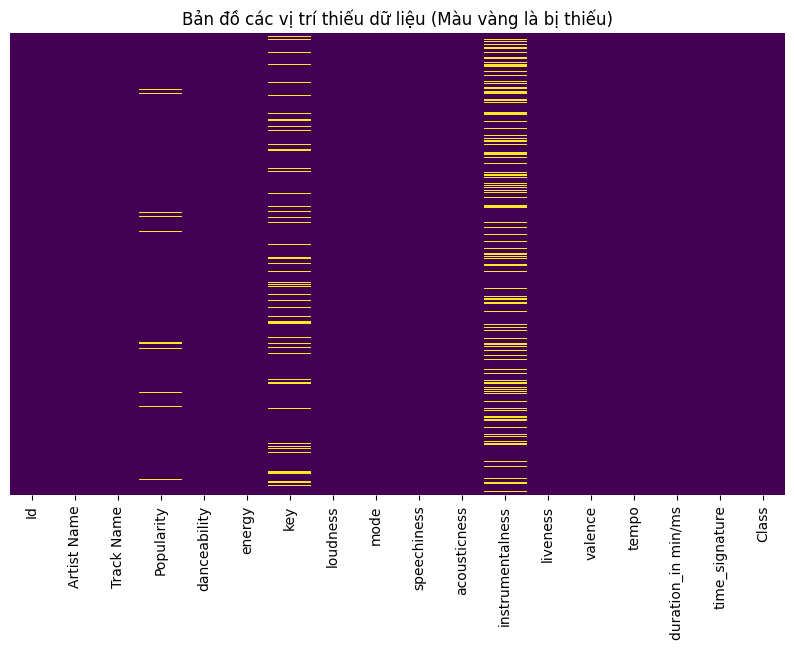

In [24]:

# Trực quan hóa giá trị thiếu
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Bản đồ các vị trí thiếu dữ liệu (Màu vàng là bị thiếu)')
plt.show()

In [25]:
# Quy đổi toàn bộ về miligiây
def fix_duration(x):
    if x < 30: # Ngưỡng 30 phút, nếu nhỏ hơn thì chắc chắn là đơn vị phút
        return x * 60000
    return x

train['duration_fixed'] = train['duration_in min/ms'].apply(fix_duration)

C:\Users\HI\AppData\Local\Temp\ipykernel_15272\3947344561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=train, palette='viridis')


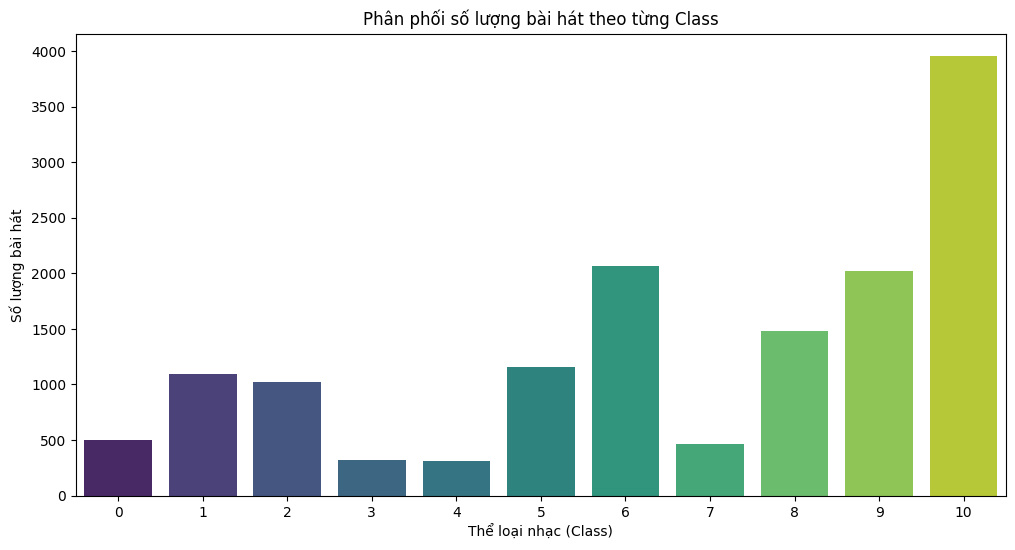

Class
10    27.500695
6     14.372048
9     14.024729
8     10.301473
5      8.036955
1      7.627119
2      7.071409
0      3.473187
7      3.202278
3      2.236732
4      2.153376
Name: proportion, dtype: float64


In [26]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Class', data=train, palette='viridis')
plt.title('Phân phối số lượng bài hát theo từng Class')
plt.xlabel('Thể loại nhạc (Class)')
plt.ylabel('Số lượng bài hát')
plt.show()

# Tính tỷ lệ phần trăm cụ thể
print(train['Class'].value_counts(normalize=True) * 100)

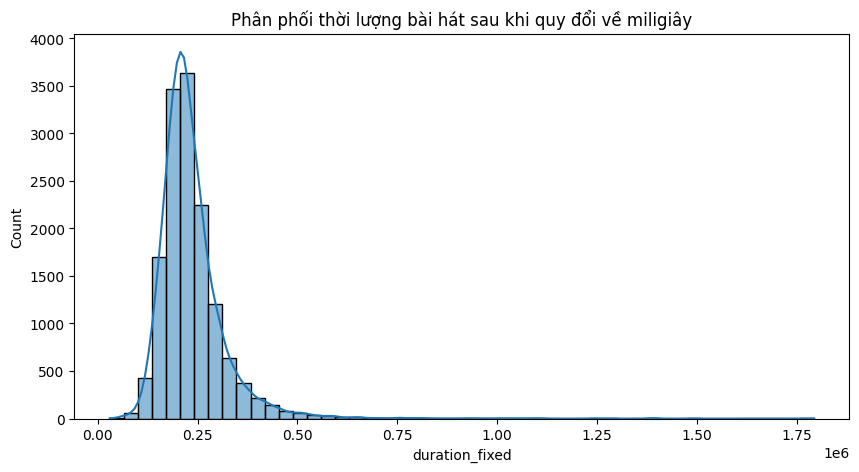

In [27]:
def fix_duration(duration):
    # Nếu thời gian < 30, ta coi đó là phút và đổi sang miligiây (30 phút là ngưỡng an toàn cho 1 bài hát)
    if duration < 30:
        return duration * 60000
    return duration

# Áp dụng hàm sửa lỗi
train['duration_fixed'] = train['duration_in min/ms'].apply(fix_duration)

# Kiểm tra thử kết quả sau khi sửa
plt.figure(figsize=(10, 5))
sns.histplot(train['duration_fixed'], bins=50, kde=True)
plt.title('Phân phối thời lượng bài hát sau khi quy đổi về miligiây')
plt.show()

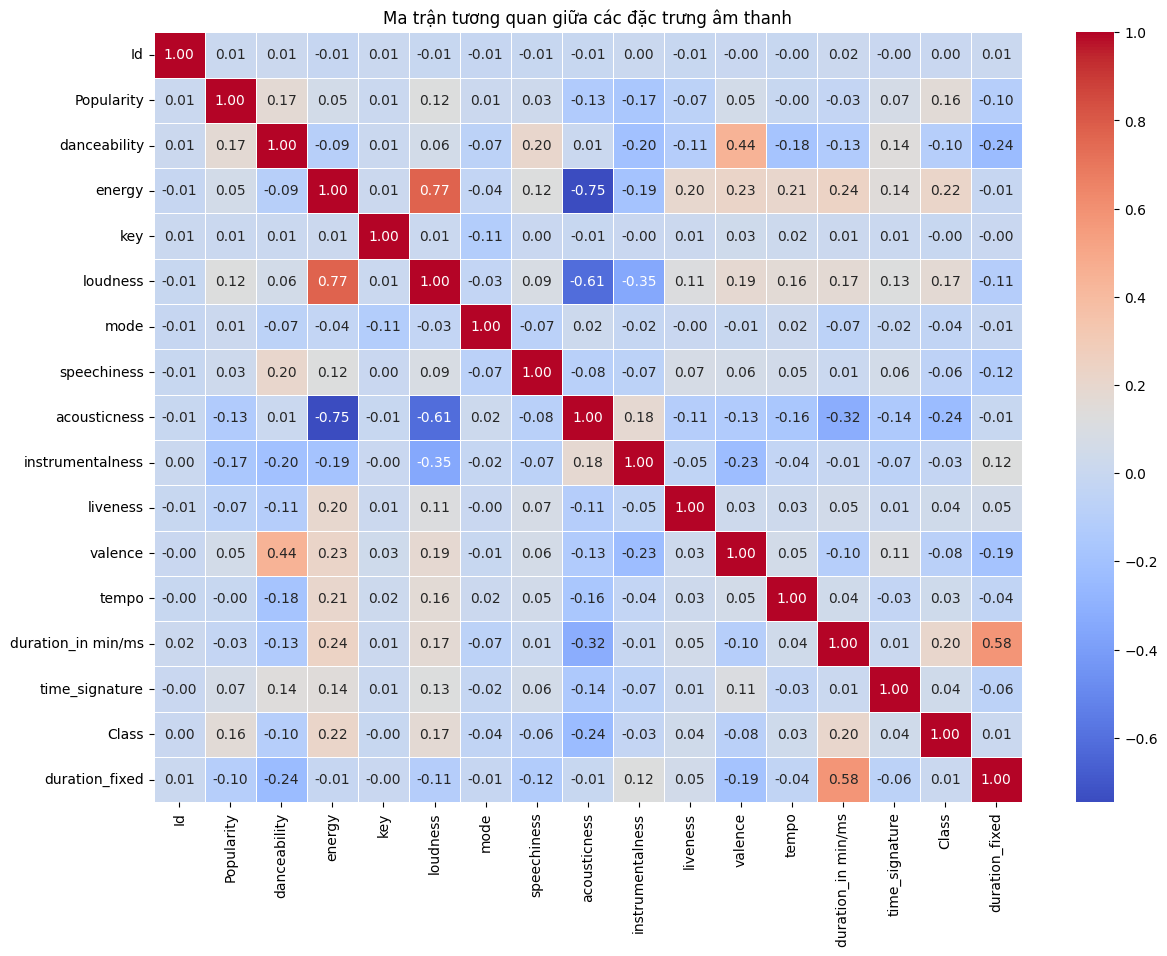

In [28]:
# Chỉ lấy các cột dữ liệu số để tính tương quan
numeric_cols = train.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng âm thanh')
plt.show()

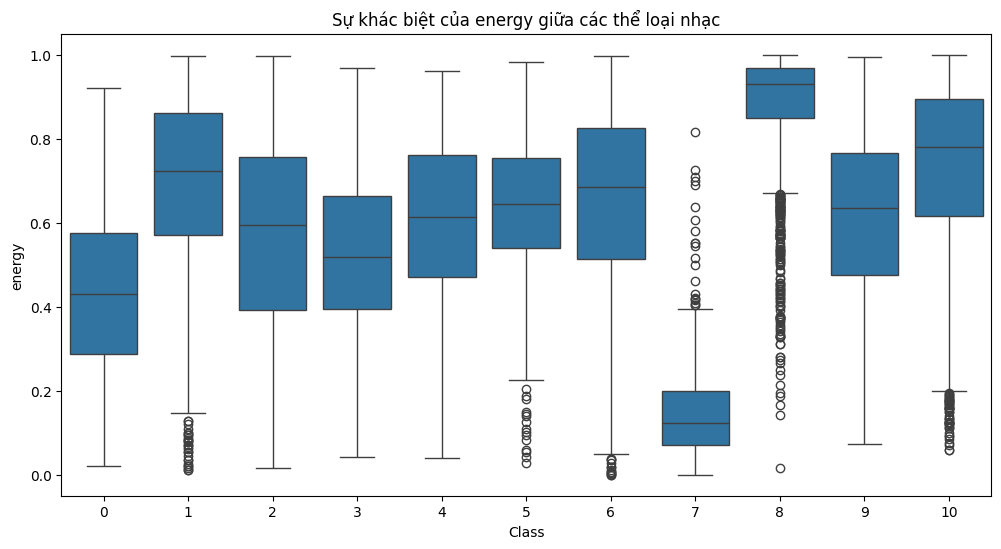

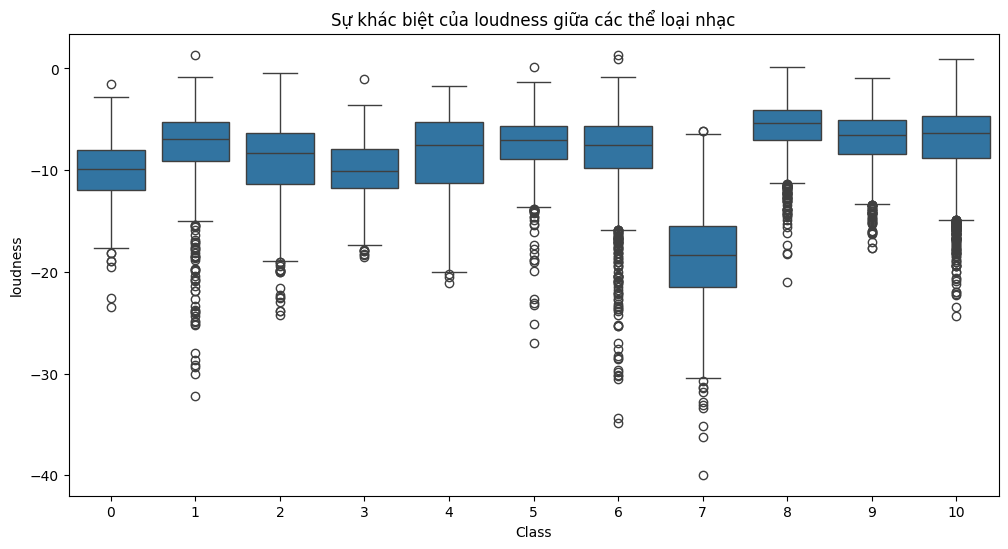

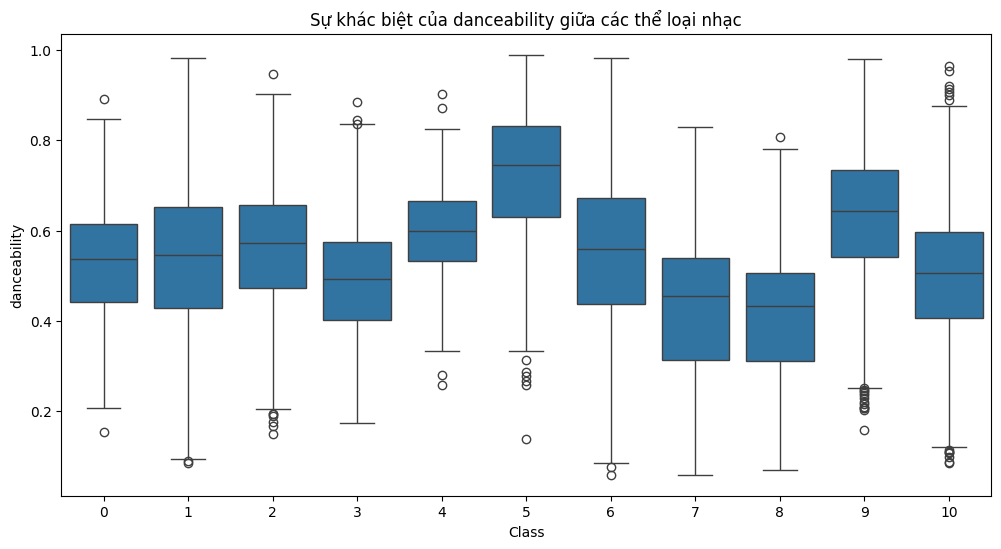

In [29]:
# Ví dụ phân tích sự khác biệt về 'Energy' và 'Loudness' giữa các Class
features_to_plot = ['energy', 'loudness', 'danceability']

for feature in features_to_plot:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Class', y=feature, data=train)
    plt.title(f'Sự khác biệt của {feature} giữa các thể loại nhạc')
    plt.show()

In [31]:
import pandas as pd

# Load dữ liệu (Đảm bảo file nằm trong thư mục data)
train = pd.read_csv('data/train (1).csv')
test = pd.read_csv('data/test (2).csv')

# 1. Xóa thẳng tay 2 cột bị hỏng nặng theo ý bạn
# Dùng errors='ignore' để tránh lỗi nếu bạn lỡ chạy code này 2 lần
train.drop(['instrumentalness', 'key'], axis=1, inplace=True, errors='ignore')
test.drop(['instrumentalness', 'key'], axis=1, inplace=True, errors='ignore')

# 2. Điền giá trị thiếu cho Popularity bằng Median (Trung vị)
# Median giúp tránh các giá trị ngoại lai (bài quá hot hoặc quá ít người nghe)
pop_median = train['Popularity'].median()
train['Popularity'] = train['Popularity'].fillna(pop_median)
test['Popularity'] = test['Popularity'].fillna(pop_median)

# 3. FIX LỖI THỜI GIAN (Cái này cực quan trọng để model chính xác)
def fix_duration(x):
    # Nếu nhỏ hơn 25 (phút), đổi sang miligiây. Ngược lại giữ nguyên.
    return x * 60000 if x < 25 else x

train['duration_in min/ms'] = train['duration_in min/ms'].apply(fix_duration)
test['duration_in min/ms'] = test['duration_in min/ms'].apply(fix_duration)

# Kiểm tra lại xem còn giá trị thiếu nào không
print("--- Kiểm tra dữ liệu sau khi xử lý ---")
print(train.isnull().sum())
print("\nCác cột hiện có:", train.columns.tolist())

--- Kiểm tra dữ liệu sau khi xử lý ---
Id                    0
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
loudness              0
mode                  0
speechiness           0
acousticness          0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64

Các cột hiện có: ['Id', 'Artist Name', 'Track Name', 'Popularity', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']


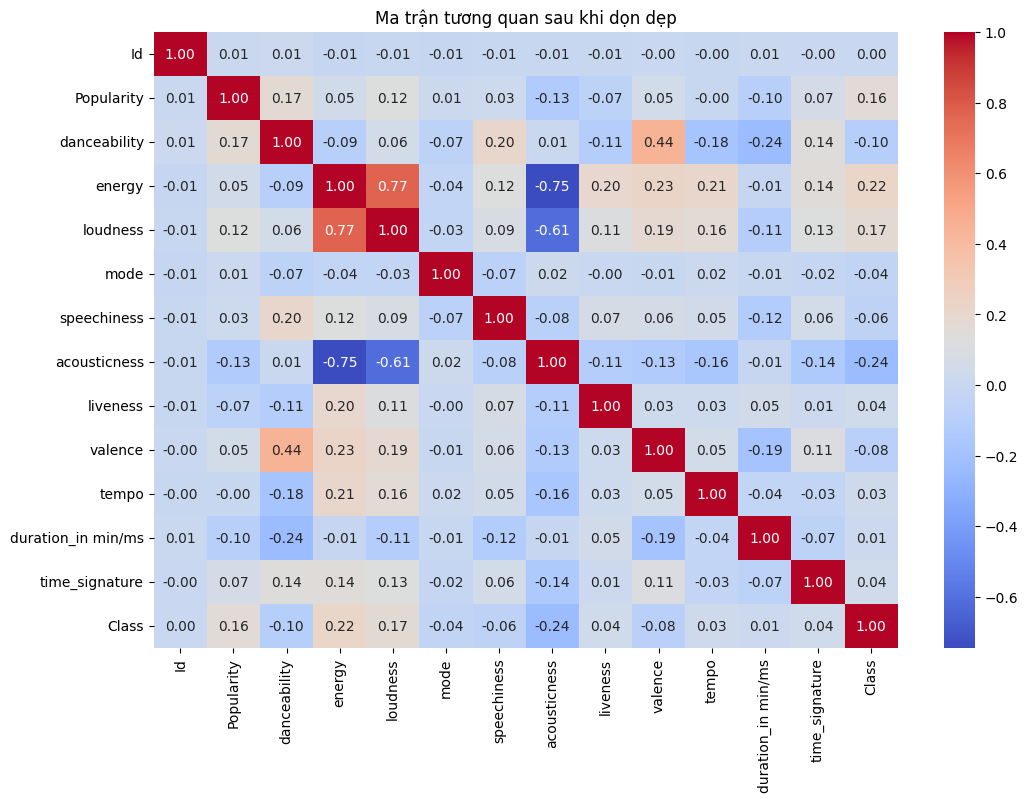

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan sau khi dọn dẹp')
plt.show()

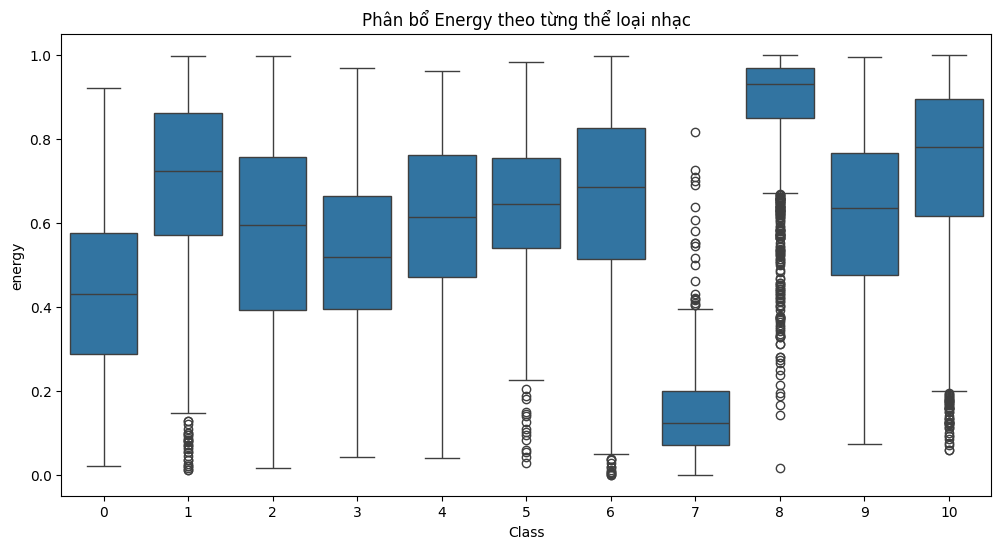

In [33]:
# Xem thử đặc trưng Energy phân bố thế nào giữa các Class
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='energy', data=train)
plt.title('Phân bổ Energy theo từng thể loại nhạc')
plt.show()

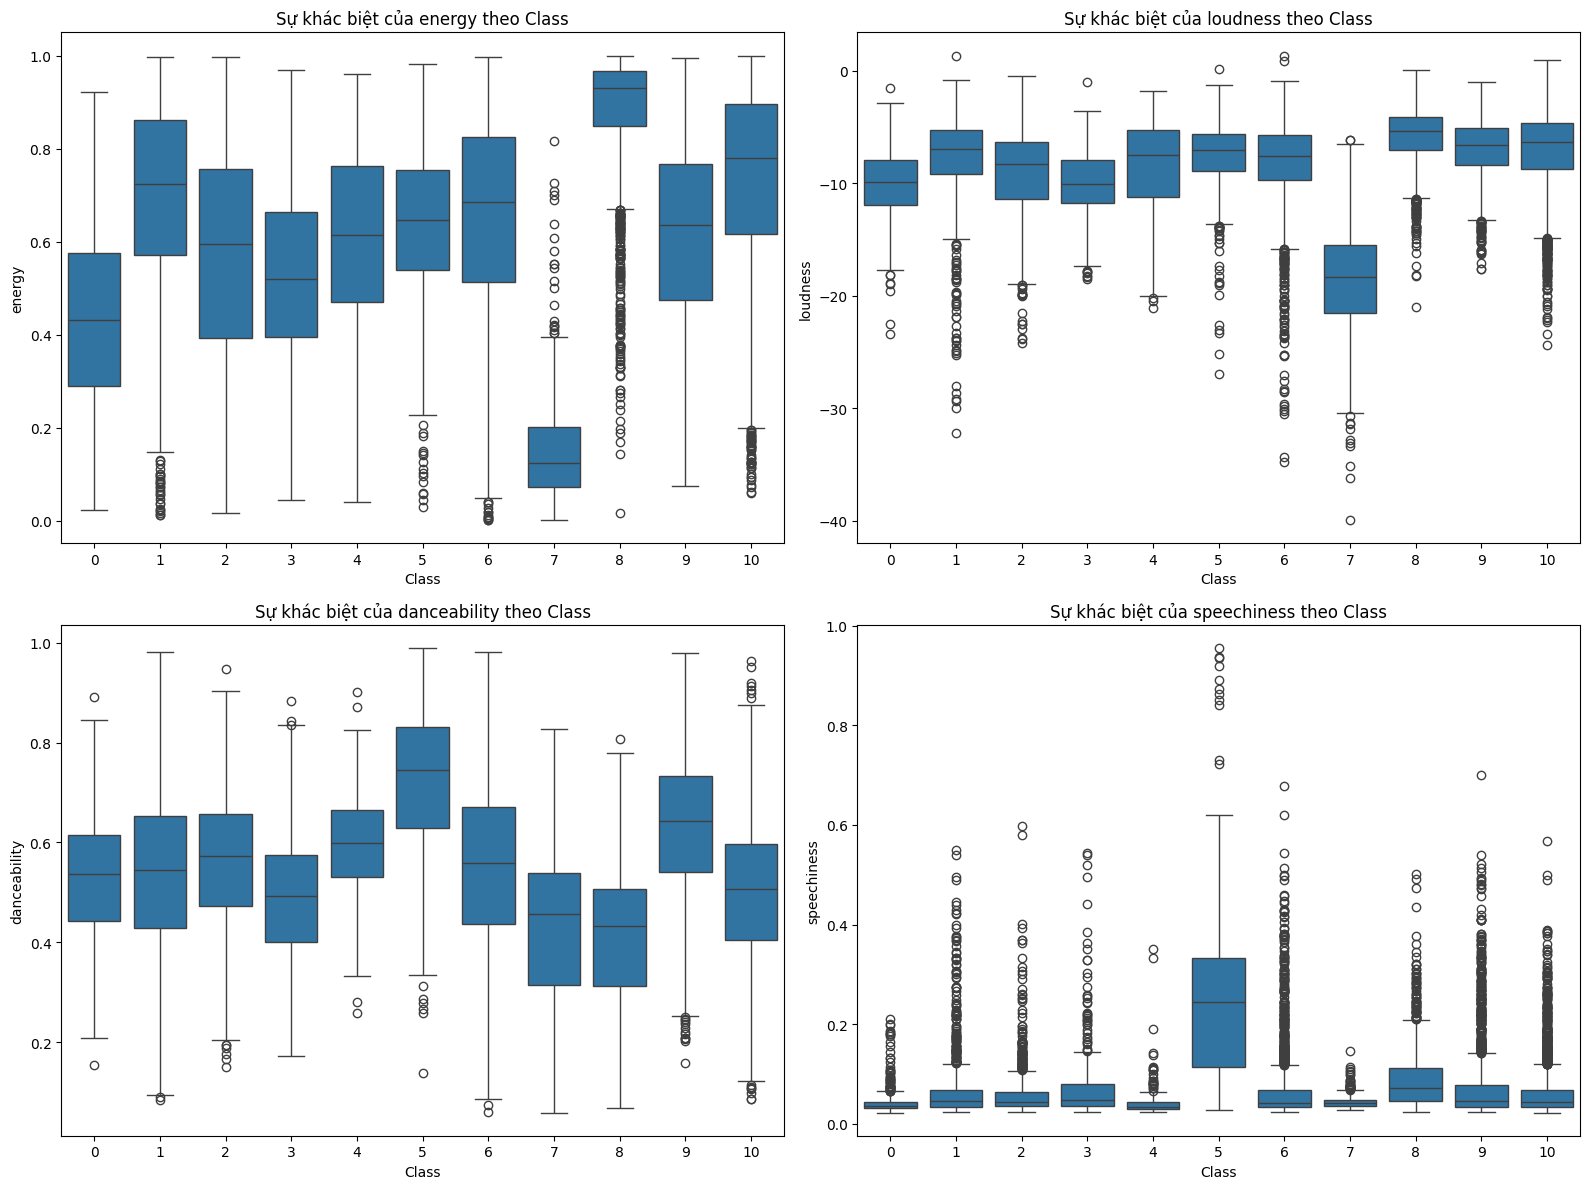

In [34]:
# Xem sự khác biệt của Energy và Loudness giữa các thể loại
features = ['energy', 'loudness', 'danceability', 'speechiness']
plt.figure(figsize=(16, 12))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='Class', y=col, data=train)
    plt.title(f'Sự khác biệt của {col} theo Class')

plt.tight_layout()
plt.show()

Top 10 nghệ sĩ xuất hiện nhiều nhất:
 Artist Name
Backstreet Boys    58
Westlife           53
Britney Spears     47
Omer Adam          39
Eyal Golan         38
Shlomo Artzi       32
Dudu Aharon        29
Arik Einstein      29
Hadag Nahash       29
Moshe Peretz       27
Name: count, dtype: int64


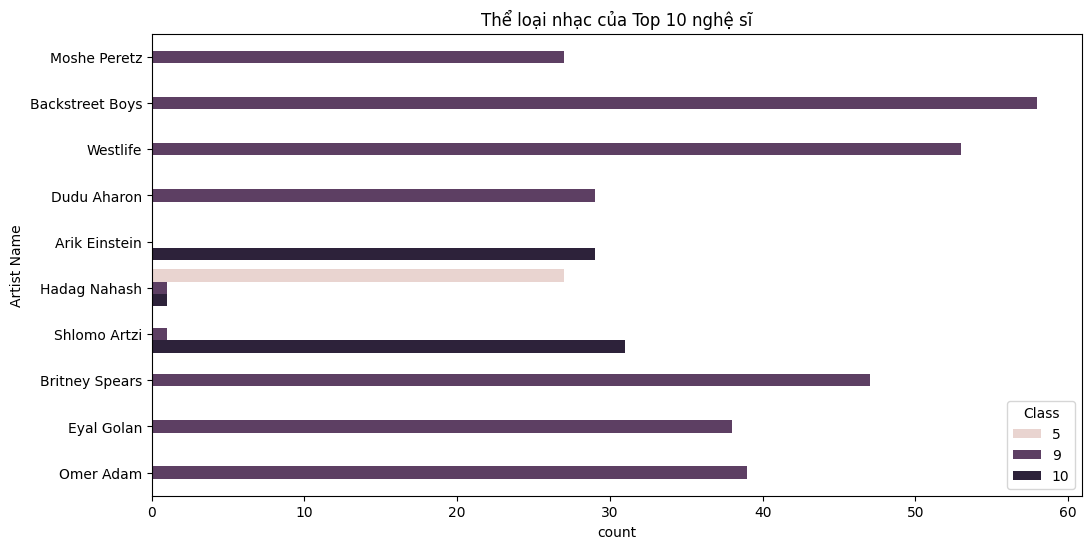

In [35]:
# Xem 10 nghệ sĩ xuất hiện nhiều nhất
top_artists = train['Artist Name'].value_counts().head(10)
print("Top 10 nghệ sĩ xuất hiện nhiều nhất:\n", top_artists)

# Trực quan hóa xem nghệ sĩ đó hát thể loại gì
plt.figure(figsize=(12, 6))
top_10_df = train[train['Artist Name'].isin(top_artists.index)]
sns.countplot(y='Artist Name', hue='Class', data=top_10_df)
plt.title('Thể loại nhạc của Top 10 nghệ sĩ')
plt.show()

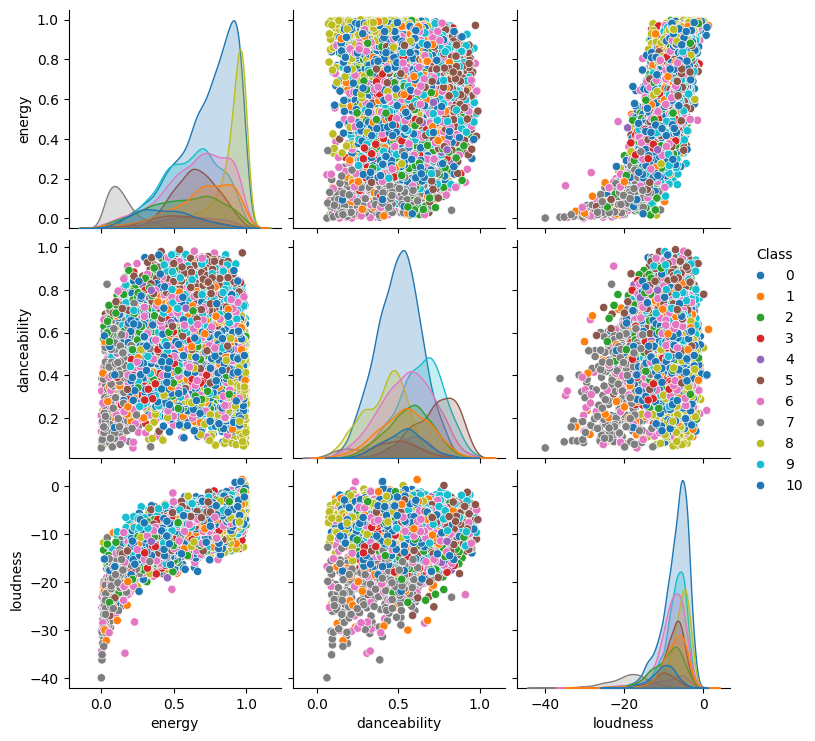

In [36]:
# Chọn vài biến đại diện để vẽ nhanh
sns.pairplot(train[['energy', 'danceability', 'loudness', 'Class']], hue='Class', palette='tab10')
plt.show()